# Artificial Intelligence (DAT6002) Week-7
## Workshop Activity 1: Developng MLP using Scikit Learn

### Module Leader: Imtiaz Hussain Khan, PhD 

#### <b style= 'color: blue'>The objective of this worksheet is to demonstrate how to build a Multi-Layer Perceptron (MLP) using Scikit-learn on the Pima Indians Diabetes Dataset. </b>

## Step 1: Import Required Libraries

### * sklearn.model_selection is used for splitting data into training and testing sets.
### * sklearn.preprocessing.StandardScaler is used for feature scaling.
### * MLPClassifier is our Multi-Layer Perceptron model.
### * sklearn.metrics provides functions for model evaluation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Step 2: Load the Dataset

In [2]:
# Note: For Google Colab, use the following code to upload the dataset

# from google.colab import files
# uploaded = files.upload()

In [3]:
df = pd.read_csv('diabetes.csv')

## Step 3: Prepare the Data
### * Split Data into Features (X) and Target Variable (y):

In [4]:
# All columns except the last one (features)
X = df.iloc[:, :-1].values

# The last column (target variable)
y =                                                                        # Complete the missing code   

### * Train-Test Split (80%-20%):

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

### * Feature Scaling 
#### - Use fit_transform(X_train) to compute the scaling parameters (mean & std).
#### - Use transform(X_test) to ensure test data is standardised using the same parameters.

In [6]:
scaler = StandardScaler()
# Fit and transform training data
X_train = scaler.fit_transform(X_train) 

# Transform test data
X_test = scaler.transform(X_test)        

## <b style= 'color: red'> Question: Why fit applies only on training data? </b>

## Step 4: Build and Train the MLP Model
### * hidden_layer_sizes=(10, ): One hidden layer with 10 neurons each.
### * activation='relu': ReLU activation function.
### * solver='adam': Adam optimiser for weight updates.
### * max_iter=500: The number of iterations for training.
### * random_state=1: Ensures reproducibility.

In [25]:
# Initialize MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(10, ), 
                    activation='relu', 
                    solver='adam',  
                    max_iter=500, 
                    random_state=1)

# Train the model
result = mlp.fit(X_train, y_train)

### Visualising Training Performance

In [ ]:
plt.plot(result.loss_curve_, label='Training Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('MLP Training Curves')
plt.legend()
plt.show()

## Step 5: Make Predictions
### * mlp.predict() takes the test data as input.
####  - It passes the test samples through the trained neural network.
####  - It computes the final output labels using activation functions.
####  - It returns the predicted class labels (0 or 1).
### * y_pred is a NumPy array containing the predicted class labels for each test sample.

In [10]:
y_pred = mlp.predict(     )                                         # Complete the missing part

## Step 6: Evaluate the Model
### * accuracy_score() computes the accuracy.
### * classification_report() provides precision, recall, and F1-score.

In [11]:
# Calculate accuracy
accuracy = accuracy_score(  ,  )                                     # Cpmplete the missing part
print(f"Accuracy: {accuracy:.2f}")

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.73
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.83      0.80        99
           1       0.65      0.56      0.60        55

    accuracy                           0.73       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154



## Step 7: Visualising Confusion Matrix
### * confusion_matrix() helps visualise true positives, false positives, false negatives, and true negatives.

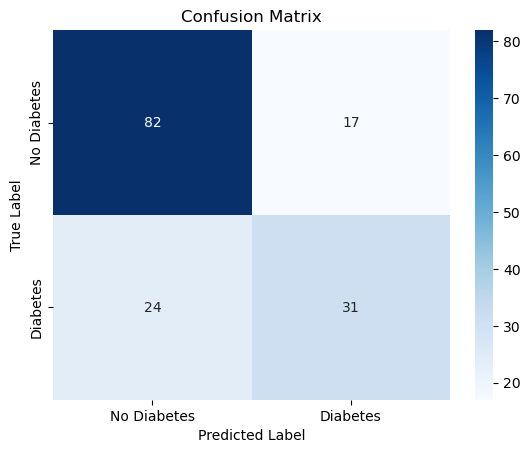

In [12]:
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["No Diabetes", "Diabetes"], yticklabels=["No Diabetes", "Diabetes"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## Step 8: Hyperparameter Tuning
### * GridSearchCV() tests multiple hyperparameter combinations.
### * cv=3 performs 3-fold cross-validation.
### * scoring='accuracy' optimises for accuracy.
### * n_jobs=-1: Use all available CPU cores for parallel processing

In [27]:
from sklearn.model_selection import GridSearchCV

In [28]:
# Define hyperparameter grid
param_grid = {
    'hidden_layer_sizes': [(10, ), (20,20), (30,30)],
    'activation': ['relu', 'tanh', 'logistic', 'identity'],
    'solver': ['adam', 'sgd'],
    'max_iter': [500, 1000, 1500]
}

In [29]:
# Perform Grid Search
grid_search = GridSearchCV(MLPClassifier(random_state=1), 
                           param_grid, 
                           cv=3, 
                           scoring='accuracy', 
                           n_jobs=-1)
gs = grid_search.fit(X_train, y_train)

### Best parameters

In [30]:
print("Best parameters:", gs.best_params_)

Best parameters: {'activation': 'identity', 'hidden_layer_sizes': (10,), 'max_iter': 500, 'solver': 'sgd'}


### Best model accuracy

In [31]:
best_model = gs.best_estimator_
y_pred_best = best_model.predict(X_test)
print("Tuned Model Accuracy:", accuracy_score(y_test, y_pred_best))

Tuned Model Accuracy: 0.7792207792207793


# Do yourself

### 1. Experiment with more hidden layers. <b style= 'color: blue'> Hint: hidden_layer_sizes=(10, 10): Two hidden layers with 10 neurons each. </b>
### 2. Explore different activation functions
### 3. Explore different optimisers
### 4. Explore other metrics such as precision, recall and f-score for GridSearch optimisation. <b style= 'color: blue'> Hint: f-score is f1 in Scikit learn.</b>
### 5. Use early stopping to stop training when validation score stops improving. <b style= 'color: blue'> Hint: Set the early_stopping to True and validation_fraction parameter in MLPClassifier to 10%, in Step 4 above. </b>